# Pipeline Explorer
**Load an image → inspect every processor individually → compose a pipeline → test end-to-end.**

| Section | Cells |
|---------|-------|
| 0 Imports & helpers | 1 |
| 1 Image source | 1 |
| 2 Processors (one per cell) | 11 |
| 3 Extractor prep + one cell per extractor | 5 |
| 4 Custom pipeline builder | 1 |
| 5 End-to-end test | 1 |

---
## 0 · Imports & Helpers

In [2]:
import math

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ── Processors ────────────────────────────────────────────────────────────────
from rlive_env.localisation.processors import (
    GrayscaleProcessor,
    GaussianBlurProcessor,
    CannyProcessor,
    LaplacianProcessor,
    ThresholdProcessor,
    DilationProcessor,
    ErosionProcessor,
    HSVProcessor,
    ChannelExtractorProcessor,
    CLAHEProcessor,
    FFTBandpassProcessor,
    ImagePipeline,
    ChannelRangeProcessor,
    InvertProcessor,
    MaskIntersectionProcessor,
)

# ── Extractors ────────────────────────────────────────────────────────────────
from rlive_env.localisation.extractors import (
    HoughCircleExtractor,
    ContourExtractor,
    MomentsExtractor,
    PolygonApproxExtractor,
)

# ── Camera ────────────────────────────────────────────────────────────────────
from rlive_world.camera.camera_factory import CameraConfig
from rlive_world.camera.camera_service import CameraService


# ── Display helper ────────────────────────────────────────────────────────────
def _to_rgb(img):
    """Convert any OpenCV image to RGB for matplotlib.
    - Grayscale (2D) → converted to 3-channel RGB
    - RGB (3-channel) → returned unchanged
    """
    if img is None:
        return np.zeros((64, 64, 3), dtype=np.uint8)
    if len(img.shape) == 2:
        return cv.cvtColor(img, cv.COLOR_GRAY2RGB)
    return img  # already RGB, no conversion needed


def show_result(processed, title="Result"):
    """Show original image next to processed result.
    Grayscale/binary outputs automatically use cmap='gray'
    so they show as black/white instead of viridis (green/purple).
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(raw_image)
    axes[0].set_title("Original")
    axes[0].axis("off")
    if processed.ndim == 2:
        axes[1].imshow(processed, cmap="gray", vmin=0, vmax=255)
    else:
        axes[1].imshow(processed)
    axes[1].set_title(title)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


print("✅  All imports OK")

✅  All imports OK


---
## 1 · Image Source
Set `USE_CAMERA = True` to grab a live frame, or `False` to load from disk.

🖼️   Loaded from disk : (480, 640, 3)
↔️   Resized to       : (480, 640, 3)


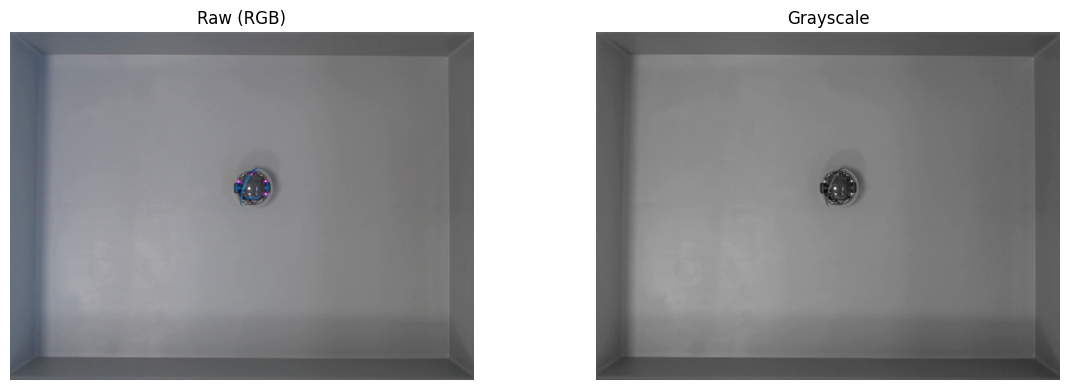

In [3]:
# ── Toggle ────────────────────────────────────────────────────────────────────
USE_CAMERA  = False                # True = grab one frame from the camera
IMAGE_PATH  = "./raw_image.png"    # path used when USE_CAMERA = False
CAMERA_TYPE = "webcam"             # "webcam" | "picam" | "dummy"
CAMERA_ID   = 2
RESIZE_TO   = (640, 480)           # (w, h) — set None to keep original size
# ─────────────────────────────────────────────────────────────────────────────

if USE_CAMERA:
    cfg = CameraConfig(type=CAMERA_TYPE, id=CAMERA_ID)
    with CameraService(config=cfg) as cam:
        raw_image = cam.get_image()
    assert raw_image is not None, "Camera returned no frame"
    print(f"📷  Camera frame  : {raw_image.shape}")
else:
    raw_image = cv.imread(IMAGE_PATH)
    assert raw_image is not None, f"Could not load image: {IMAGE_PATH}"
    print(f"🖼️   Loaded from disk : {raw_image.shape}")

if RESIZE_TO:
    raw_image = cv.resize(raw_image, RESIZE_TO)
    print(f"↔️   Resized to       : {raw_image.shape}")

# Convert from OpenCV's default BGR load to RGB (all processors now expect RGB)
raw_image  = cv.cvtColor(raw_image, cv.COLOR_BGR2RGB)

# Pre-computed grayscale used by processor cells below
gray_image = cv.cvtColor(raw_image, cv.COLOR_RGB2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(raw_image);                     axes[0].set_title("Raw (RGB)");  axes[0].axis("off")
axes[1].imshow(gray_image, cmap="gray");       axes[1].set_title("Grayscale"); axes[1].axis("off")
plt.tight_layout()
plt.show()

---
## 1.5 · Color Space Overview
How the same image looks in different colour representations.
Useful reference before choosing which pipeline steps to apply.

### Color spaces explained

| Space | What it encodes | Why useful |
|-------|----------------|------------|
| **RGB** | Red, Green, Blue light intensities | Standard display format; what you "see" |
| **Grayscale** | Single luminosity channel (weighted RGB average) | Reduces data; required input for Canny, Laplacian, FFT, CLAHE, Threshold |
| **HSV** | **Hue** (colour type 0–180°), **Saturation** (vivid vs grey), **Value** (brightness) | Best for colour-based masking — H stays stable under lighting changes; tweak S & V to reject shadows |
| → H channel | The colour angle on the wheel (red≈0, green≈60, blue≈110, etc.) | Isolate a specific colour regardless of brightness |
| → S channel | How "colourful" a pixel is — grey/white/black pixels → S≈0 | Filter out neutral background areas |
| → V channel | How bright a pixel is — like a grayscale but perceptually different from RGB grey | Reject dark shadows or overexposed regions |
| **LAB** | **L** (lightness), **A** (green↔red axis), **B** (blue↔yellow axis) | Perceptually uniform: equal numeric distance = equal visual difference; good for colour distance measures |
| → L channel | Pure lightness, decoupled from colour | Background subtraction insensitive to hue |
| → A channel | Encodes how red vs. green a pixel is | Useful to separate warm vs cool colours |
| → B channel | Encodes how yellow vs. blue a pixel is | |
| **YCrCb** | **Y** (luma/brightness), **Cr** (red colour diff), **Cb** (blue colour diff) | Standard in video/JPEG; Y≈perceptual brightness; Cr+Cb carry colour info separately |
| → Y channel | Perceived brightness (weighted: 0.299R + 0.587G + 0.114B) | Very similar to grayscale but more perceptually accurate |
| → Cr channel | How much more red than average | Skin-tone detection; warm colour isolation |
| → Cb channel | How much more blue than average | Cool colour / sky / water isolation |

> **Quick rule of thumb for ball detection:**
> → If the ball has a distinct colour → use **HSV mask** (H range)
> → If the ball is brighter/darker than background → use **V (HSV)** or **L (LAB)**
> → If the scene has uneven lighting → try **CLAHE on L (LAB)** first

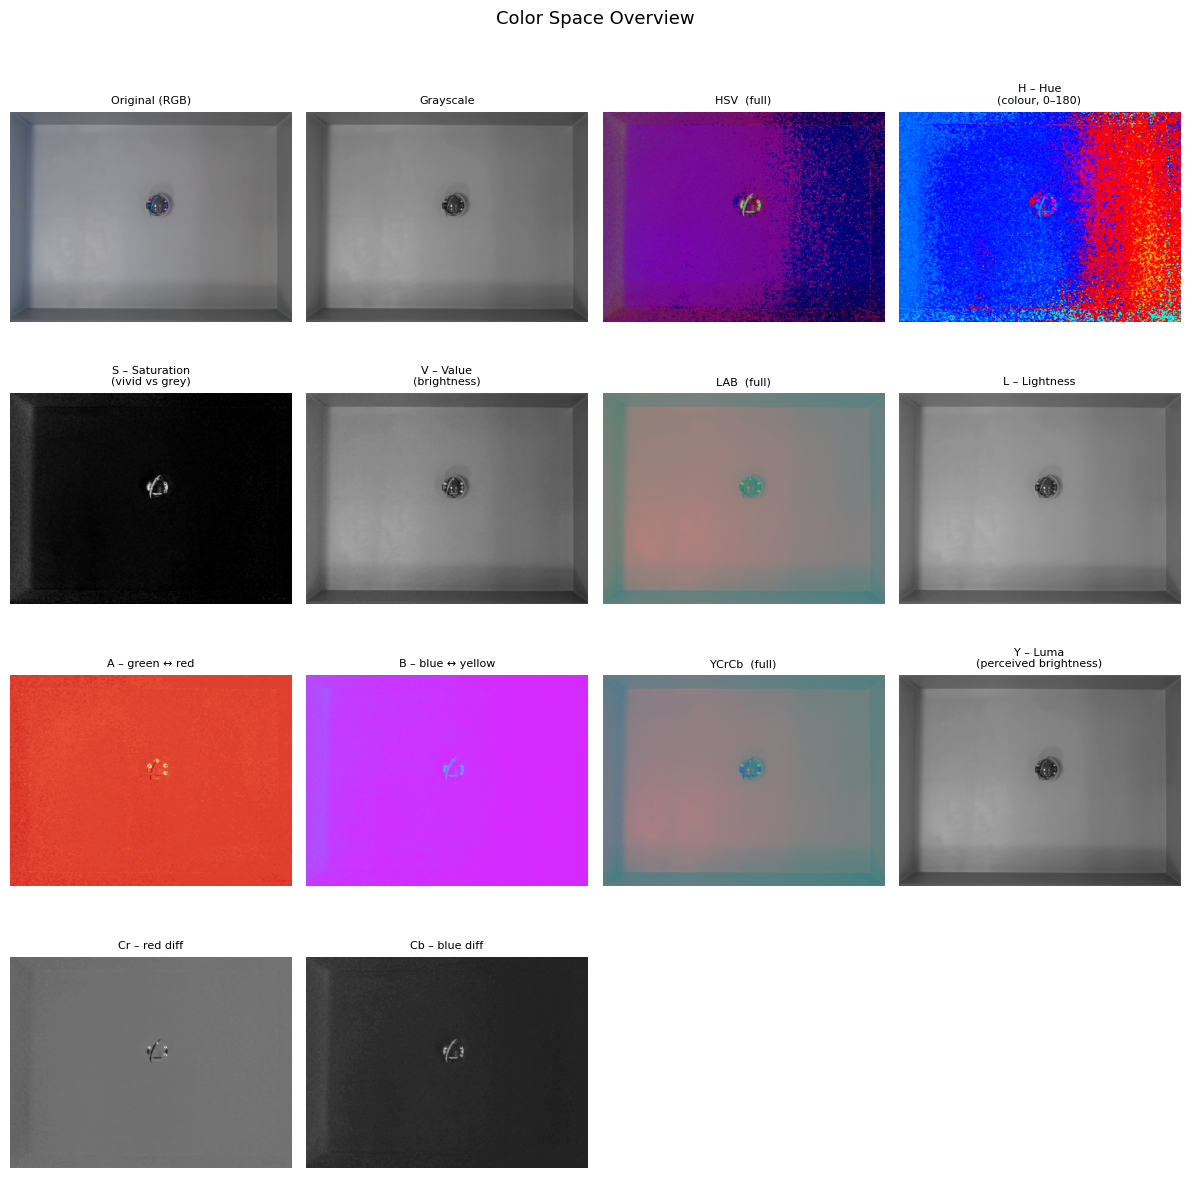

In [4]:
# ── Color Space Overview ──────────────────────────────────────────────────────
# Shows the image in every major colour space + individual channels.
# Run this cell once after loading an image to get your bearings.

hsv_img  = cv.cvtColor(raw_image, cv.COLOR_RGB2HSV)
lab_img  = cv.cvtColor(raw_image, cv.COLOR_RGB2LAB)
ycr_img  = cv.cvtColor(raw_image, cv.COLOR_RGB2YCrCb)

views = [
    # (display image,              cmap,    label)
    (raw_image,                    None,    "Original (RGB)"),   # already RGB
    (gray_image,                   "gray",  "Grayscale"),

    # ── HSV ───────────────────────────────────────────────────────────────────
    (_to_rgb(hsv_img),             None,    "HSV  (full)"),
    (hsv_img[:, :, 0],             "hsv",   "H – Hue\n(colour, 0–180)"),
    (hsv_img[:, :, 1],             "gray",  "S – Saturation\n(vivid vs grey)"),
    (hsv_img[:, :, 2],             "gray",  "V – Value\n(brightness)"),

    # ── LAB ───────────────────────────────────────────────────────────────────
    (_to_rgb(lab_img),             None,    "LAB  (full)"),
    (lab_img[:, :, 0],             "gray",  "L – Lightness"),
    (lab_img[:, :, 1],             "RdYlGn","A – green ↔ red"),
    (lab_img[:, :, 2],             "cool",  "B – blue ↔ yellow"),

    # ── YCrCb ─────────────────────────────────────────────────────────────────
    (_to_rgb(ycr_img),             None,    "YCrCb  (full)"),
    (ycr_img[:, :, 0],             "gray",  "Y – Luma\n(perceived brightness)"),
    (ycr_img[:, :, 1],             "gray",  "Cr – red diff"),
    (ycr_img[:, :, 2],             "gray",  "Cb – blue diff"),
]

cols = 4
rows = (len(views) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for ax, (img, cmap, label) in zip(axes, views):
    ax.imshow(img, cmap=cmap)
    ax.set_title(label, fontsize=8)
    ax.axis("off")

for ax in axes[len(views):]:   # hide unused subplots
    ax.set_visible(False)

plt.suptitle("Color Space Overview", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 2 · Processors
Each cell is self-contained — tweak the parameters at the top and re-run.

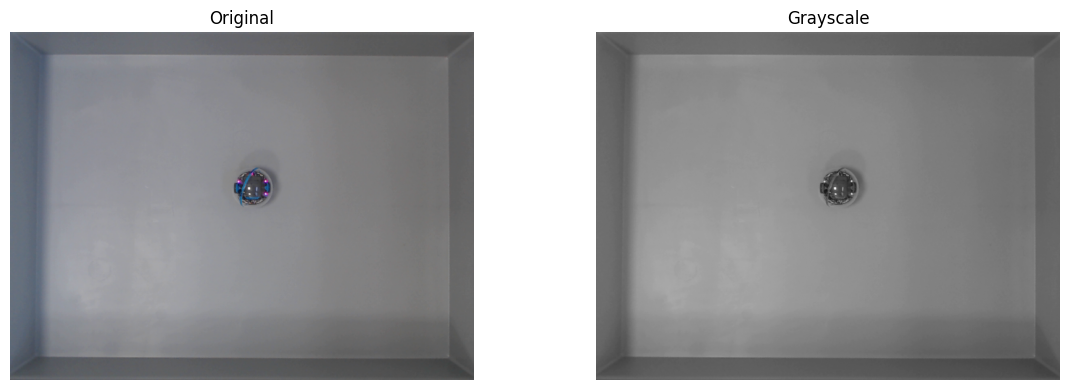

In [5]:
# ── GrayscaleProcessor ────────────────────────────────────────────────────────
# Converts a BGR image to a single-channel intensity image.
# Input: BGR   Output: grayscale

proc   = GrayscaleProcessor()
result = proc.process(raw_image)
show_result(result, proc.name)

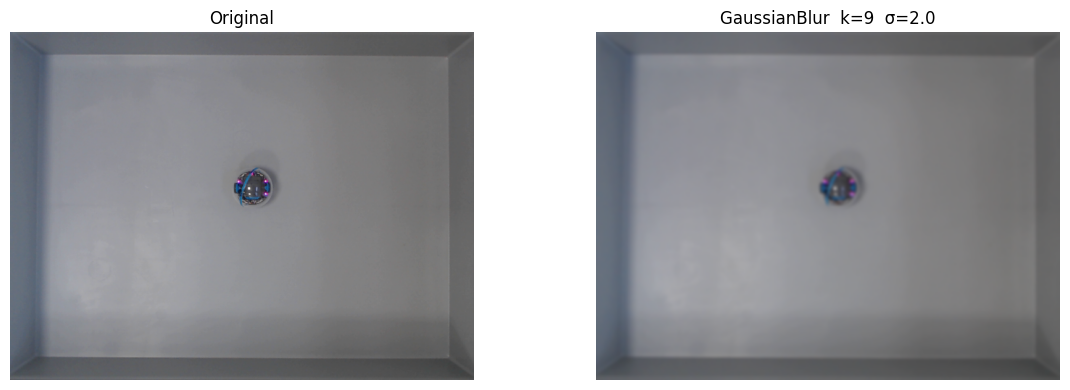

In [6]:
# ── GaussianBlurProcessor ─────────────────────────────────────────────────────
# Smooths the image with a Gaussian kernel to suppress noise.
# Input: BGR or grayscale   Output: same channels, blurred

KERNEL_SIZE = 9     # must be odd
SIGMA       = 2.0

proc   = GaussianBlurProcessor(kernel_size=KERNEL_SIZE, sigma=SIGMA)
result = proc.process(raw_image)
show_result(result, f"{proc.name}  k={KERNEL_SIZE}  σ={SIGMA}")

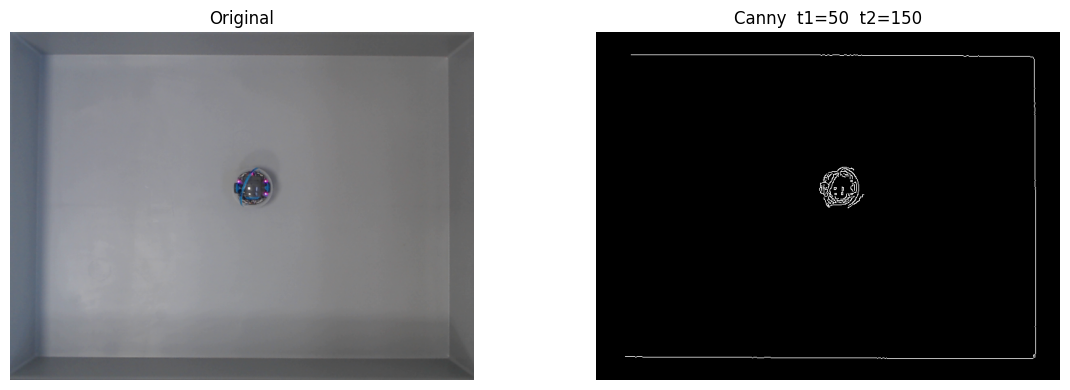

In [7]:
# ── CannyProcessor ────────────────────────────────────────────────────────────
# Detects edges using the Canny algorithm (hysteresis thresholding).
# Input: grayscale   Output: binary edge map

THRESHOLD1 = 50
THRESHOLD2 = 150
APERTURE   = 3     # 3 | 5 | 7

proc   = CannyProcessor(threshold1=THRESHOLD1, threshold2=THRESHOLD2, aperture=APERTURE)
result = proc.process(gray_image)
show_result(result, f"{proc.name}  t1={THRESHOLD1}  t2={THRESHOLD2}")

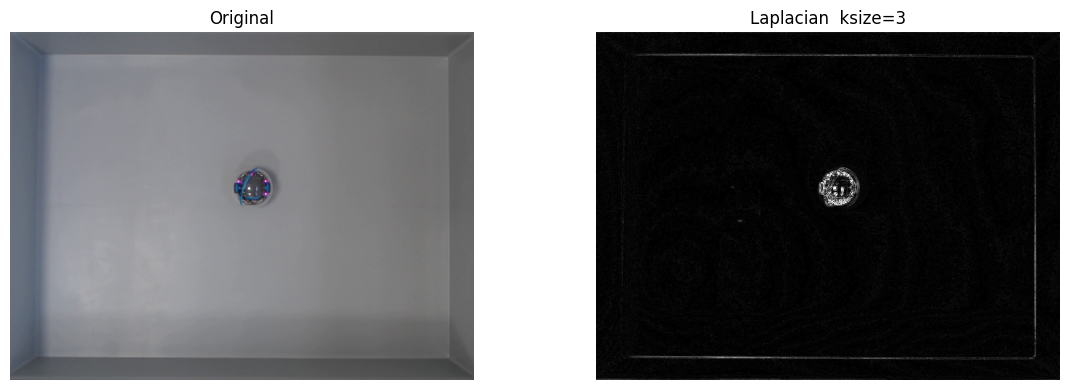

In [8]:
# ── LaplacianProcessor ────────────────────────────────────────────────────────
# Applies the Laplacian operator to highlight regions of rapid intensity change.
# Input: grayscale   Output: abs(Laplacian) as uint8

KSIZE = 3     # 1 | 3 | 5 | 7

proc   = LaplacianProcessor(ksize=KSIZE)
result = proc.process(gray_image)
show_result(result, f"{proc.name}  ksize={KSIZE}")

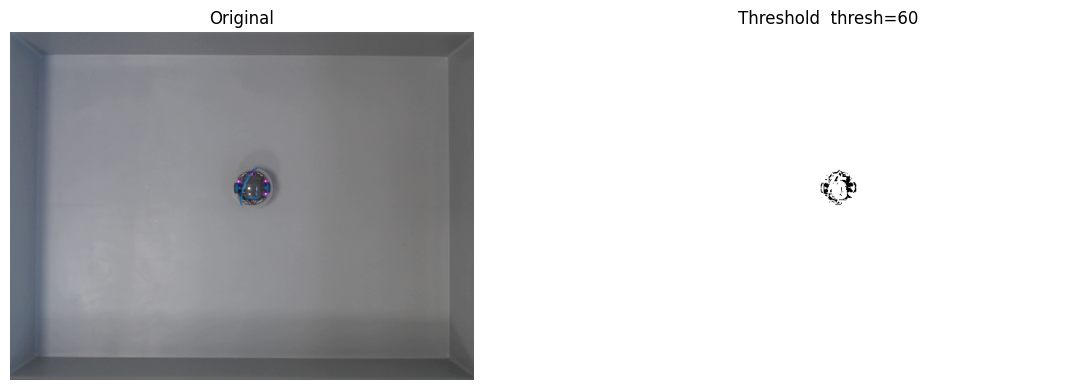

In [9]:
# ── ThresholdProcessor ────────────────────────────────────────────────────────
# Binarises a grayscale image: pixels > THRESHOLD_VALUE → MAX_VALUE, else 0.
# Input: grayscale   Output: binary (0 / 255)

THRESHOLD_VALUE = 60
MAX_VALUE       = 255

proc         = ThresholdProcessor(threshold_value=THRESHOLD_VALUE, max_value=MAX_VALUE)
result       = proc.process(gray_image)
binary_image = result   # ← reused by Dilation / Erosion cells
show_result(result, f"{proc.name}  thresh={THRESHOLD_VALUE}")

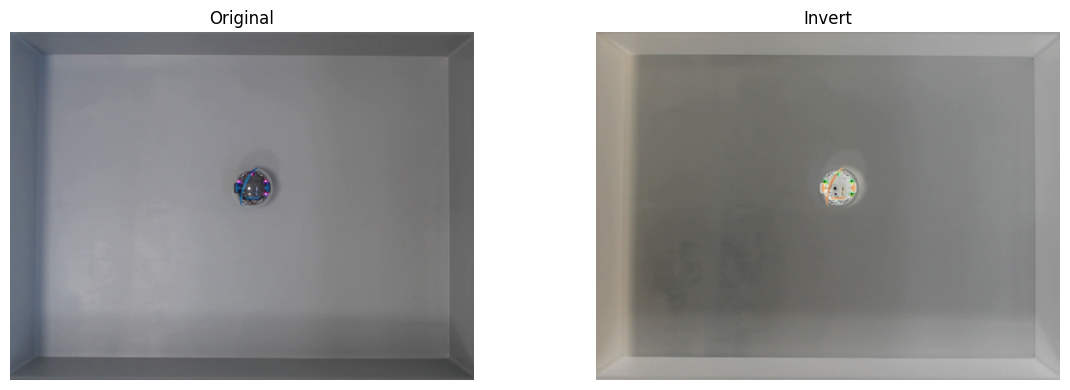

In [10]:
# ── InvertProcessor ────────────────────────────────────────────────────────────
# Inverts an image by flipping every pixel value: p → 255 - p.
# Works on binary masks, grayscale, and colour (RGB/BGR) images.
# Input: any image   Output: same shape/dtype, values inverted

proc          = InvertProcessor()
result        = proc.process(raw_image)
inverted_image = result   # ← e.g. pass into next processor or use as mask
show_result(result, proc.name)

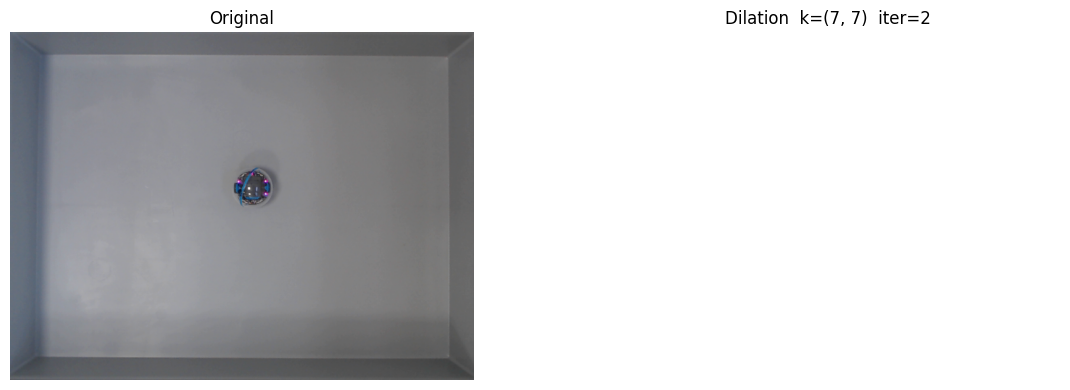

In [11]:
# ── DilationProcessor ─────────────────────────────────────────────────────────
# Morphological dilation: expands bright regions, fills small holes.
# Input: binary (uses binary_image from ThresholdProcessor cell above)
# Output: dilated binary

KERNEL_SIZE = (7, 7)
ITERATIONS  = 2

proc   = DilationProcessor(kernel_size=KERNEL_SIZE, iterations=ITERATIONS)
result = proc.process(binary_image)
show_result(result, f"{proc.name}  k={KERNEL_SIZE}  iter={ITERATIONS}")

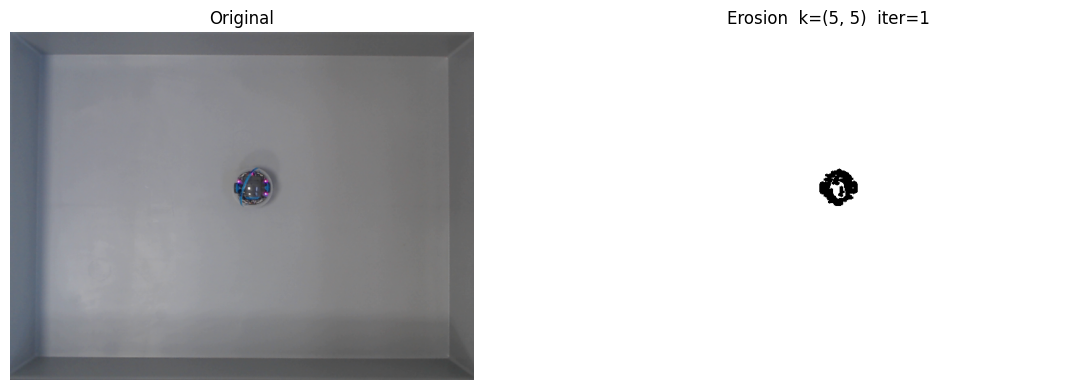

In [12]:
# ── ErosionProcessor ──────────────────────────────────────────────────────────
# Morphological erosion: shrinks bright regions, removes small noise blobs.
# Input: binary (uses binary_image from ThresholdProcessor cell above)
# Output: eroded binary

KERNEL_SIZE = (5, 5)
ITERATIONS  = 1

proc   = ErosionProcessor(kernel_size=KERNEL_SIZE, iterations=ITERATIONS)
result = proc.process(binary_image)
show_result(result, f"{proc.name}  k={KERNEL_SIZE}  iter={ITERATIONS}")

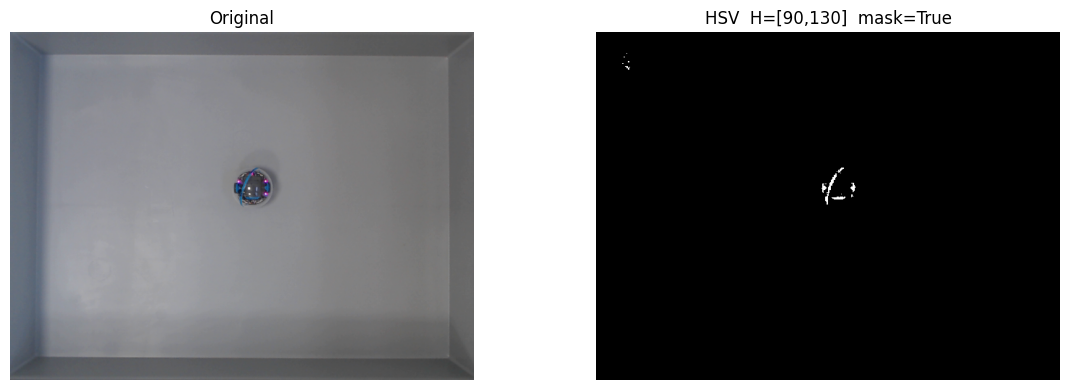

In [13]:
# ── HSVProcessor ──────────────────────────────────────────────────────────────
# Converts BGR → HSV and optionally creates a binary color-range mask.
# apply_mask=False  → returns 3-channel HSV image
# apply_mask=True   → returns binary mask of pixels inside the H/S/V range
# Input: BGR   Output: HSV image or binary mask

LOWER_HUE  = 90;  UPPER_HUE  = 130   # 0–180  (OpenCV hue scale)
LOWER_SAT  = 80;  UPPER_SAT  = 255   # 0–255
LOWER_VAL  = 100;  UPPER_VAL  = 255   # 0–255
APPLY_MASK = True

proc   = HSVProcessor(
    lower_hue=LOWER_HUE, upper_hue=UPPER_HUE,
    lower_sat=LOWER_SAT, upper_sat=UPPER_SAT,
    lower_val=LOWER_VAL, upper_val=UPPER_VAL,
    apply_mask=APPLY_MASK,
)
result = proc.process(raw_image)
show_result(result, f"{proc.name}  H=[{LOWER_HUE},{UPPER_HUE}]  mask={APPLY_MASK}")

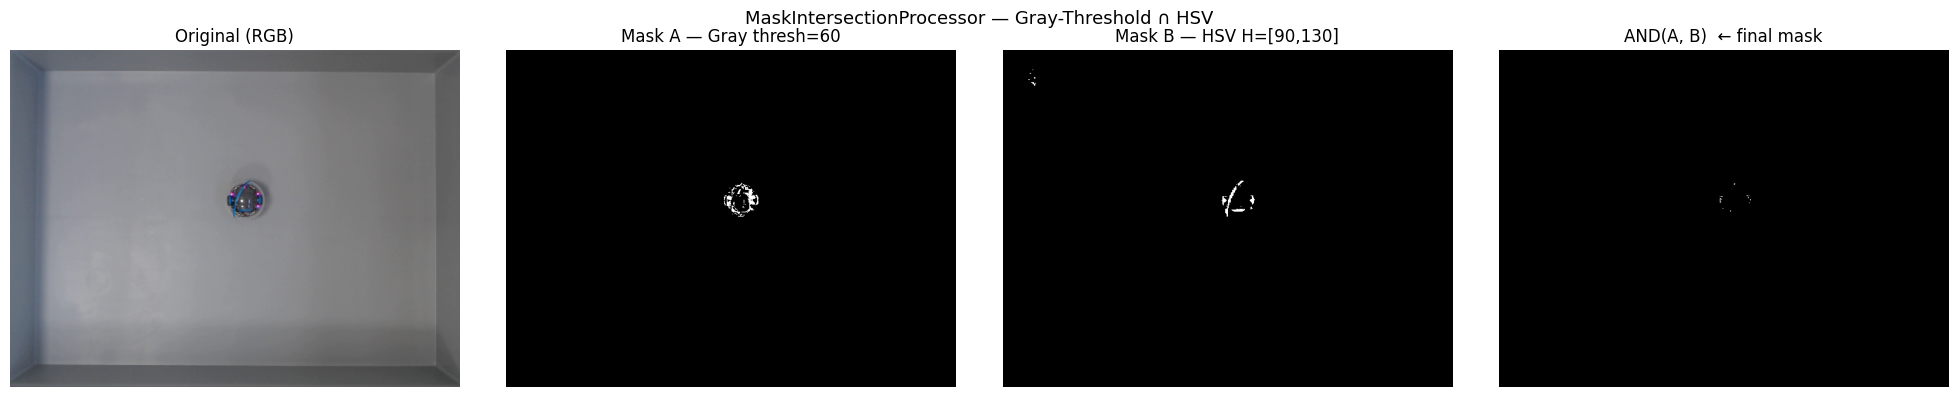

Non-zero px  →  mask_a: 552  |  mask_b: 360  |  AND: 26


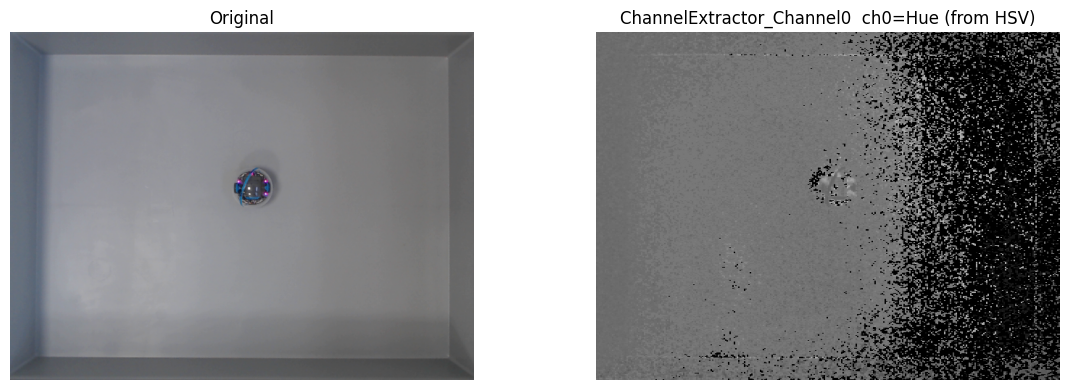

In [14]:
# ── MaskIntersectionProcessor ─────────────────────────────────────────────────
# Runs TWO sub-pipelines on the SAME original image and returns
# the bitwise AND of the two resulting binary masks.
#
#   mask_a  =  gray-threshold pipeline  →  bright pixels survive
#   mask_b  =  HSV color-range pipeline →  correctly-coloured pixels survive
#   result  =  AND(mask_a, mask_b)      →  only bright AND correctly-coloured pixels
#
# This drastically reduces false positives compared to using either mask alone.
# Input: RGB image   Output: binary mask (0 / 255)

# ── Gray-threshold branch ─────────────────────────────────────────────────────
THRESHOLD_VALUE = 60

# ── HSV color branch ──────────────────────────────────────────────────────────
LOWER_HUE  = 90;  UPPER_HUE  = 130
LOWER_SAT  = 80;  UPPER_SAT  = 255
LOWER_VAL  = 100; UPPER_VAL  = 255

gray_pipeline = ImagePipeline([
    GrayscaleProcessor(),
    ThresholdProcessor(threshold_value=THRESHOLD_VALUE),
    InvertProcessor(),
])

hsv_pipeline = ImagePipeline([
    HSVProcessor(
        lower_hue=LOWER_HUE, upper_hue=UPPER_HUE,
        lower_sat=LOWER_SAT, upper_sat=UPPER_SAT,
        lower_val=LOWER_VAL, upper_val=UPPER_VAL,
        apply_mask=True,
    ),
])

proc = MaskIntersectionProcessor(gray_pipeline, hsv_pipeline)

# Run each branch individually so we can inspect all three masks side-by-side
mask_a    = gray_pipeline.execute(raw_image.copy())
mask_b    = hsv_pipeline.execute(raw_image.copy())
result    = proc.process(raw_image)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].imshow(raw_image);              axes[0].set_title("Original (RGB)");          axes[0].axis("off")
axes[1].imshow(mask_a, cmap="gray");    axes[1].set_title(f"Mask A — Gray thresh={THRESHOLD_VALUE}"); axes[1].axis("off")
axes[2].imshow(mask_b, cmap="gray");    axes[2].set_title(f"Mask B — HSV H=[{LOWER_HUE},{UPPER_HUE}]"); axes[2].axis("off")
axes[3].imshow(result, cmap="gray");    axes[3].set_title("AND(A, B)  ← final mask"); axes[3].axis("off")
plt.suptitle("MaskIntersectionProcessor — Gray-Threshold ∩ HSV", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Non-zero px  →  mask_a: {(mask_a > 0).sum()}  |  mask_b: {(mask_b > 0).sum()}  |  AND: {(result > 0).sum()}")
# Extracts a single channel from a 3-channel image.
# Applied here to an HSV image:
#   CHANNEL = 0  → Hue     (colour wheel angle)
#   CHANNEL = 1  → Saturation
#   CHANNEL = 2  → Value   (brightness)
# Input: 3-channel (HSV or BGR)   Output: grayscale single channel

CHANNEL = 0    # 0 | 1 | 2

hsv_img = cv.cvtColor(raw_image, cv.COLOR_RGB2HSV)
proc    = ChannelExtractorProcessor(channel=CHANNEL)
result  = proc.process(hsv_img)
channel_label = ["Hue", "Saturation", "Value"][CHANNEL]
show_result(result, f"{proc.name}  ch{CHANNEL}={channel_label} (from HSV)")

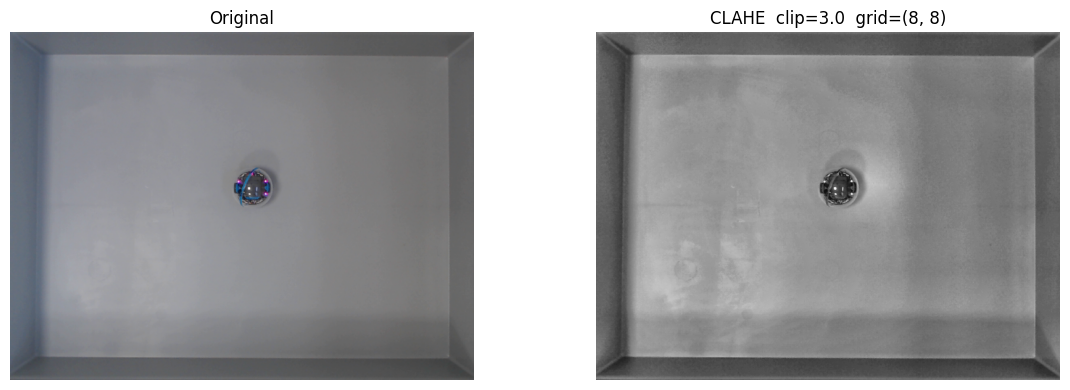

In [15]:
# ── CLAHEProcessor ────────────────────────────────────────────────────────────
# Contrast-Limited Adaptive Histogram Equalisation.
# Boosts local contrast — useful when ball and background have similar brightness.
# Input: grayscale   Output: contrast-enhanced grayscale

CLIP_LIMIT     = 3.0
TILE_GRID_SIZE = (8, 8)

proc   = CLAHEProcessor(clip_limit=CLIP_LIMIT, tile_grid_size=TILE_GRID_SIZE)
result = proc.process(gray_image)
show_result(result, f"{proc.name}  clip={CLIP_LIMIT}  grid={TILE_GRID_SIZE}")

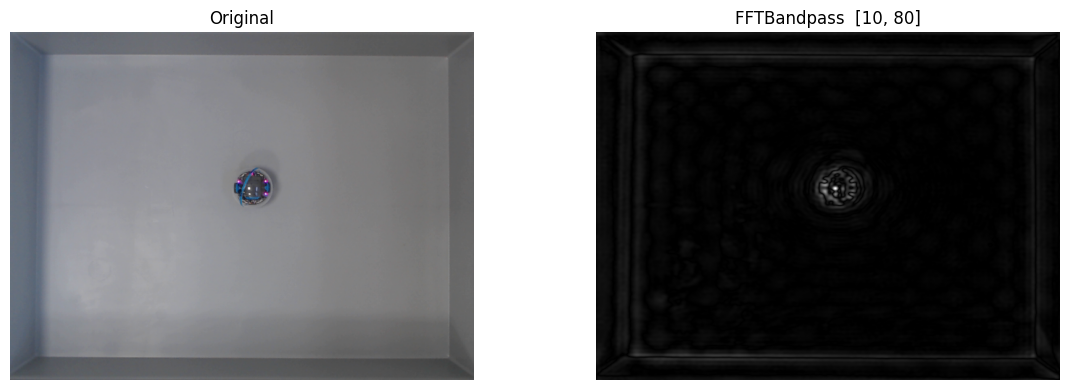

In [16]:
# ── FFTBandpassProcessor ──────────────────────────────────────────────────────
# Keeps only the spatial frequency band [LOW_FREQ, HIGH_FREQ].
# Useful for emphasising circular structures and suppressing background texture.
# Input: grayscale   Output: bandpass-filtered grayscale (uint8, normalised)

LOW_FREQ  = 10
HIGH_FREQ = 80

proc   = FFTBandpassProcessor(low_freq=LOW_FREQ, high_freq=HIGH_FREQ)
result = proc.process(gray_image)
show_result(result, f"{proc.name}  [{LOW_FREQ}, {HIGH_FREQ}]")

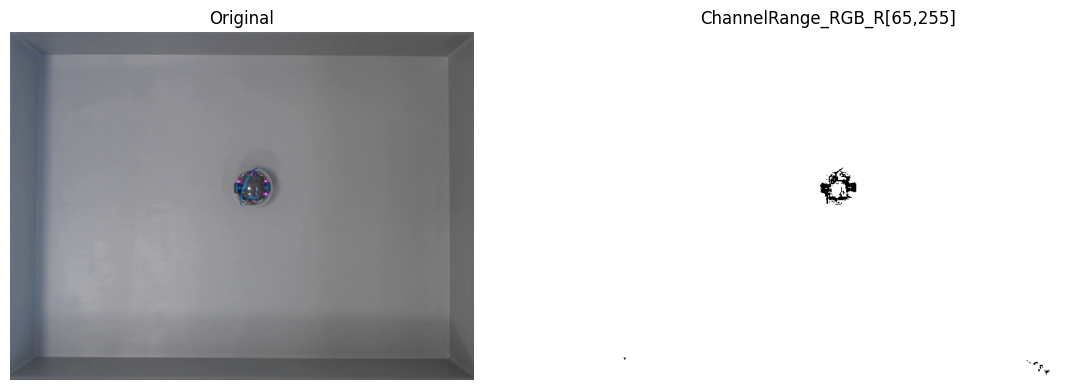

In [17]:
# ── ChannelRangeProcessor ─────────────────────────────────────────────────────
# Convert to a colour space → extract ONE channel → binary range mask.
# All in one step. Useful for shadow rejection and quick colour isolation.
#
# color_space options : "bgr" | "rgb" | "hsv" | "lab" | "ycrcb" | "gray"
# channel             : 0 / 1 / 2  (see table in Section 1.5)
# lower / upper       : keep pixels whose channel value is in [lower, upper]
#
# Shadow rejection example:
#   Shadows have low V in HSV.  Set lower=90 to exclude them from the mask.
#       color_space="hsv", channel=2 (V), lower=90, upper=255
#
# Colour isolation example:
#   Extract only pixels where the Hue is in the blue range:
#       color_space="hsv", channel=0 (H), lower=100, upper=130

COLOR_SPACE = "rgb"   # ← change me
CHANNEL     = 0
LOWER       = 65      # minimum channel value to keep
UPPER       = 255     # maximum channel value to keep

proc   = ChannelRangeProcessor(color_space=COLOR_SPACE, channel=CHANNEL, lower=LOWER, upper=UPPER)
result = proc.process(raw_image)
show_result(result, proc.name)

---
## 3 · Extractors
Extractors take a **binary / processed** image and return a `BallLocation`.
The cell below builds a quick binary mask used by all extractor cells.

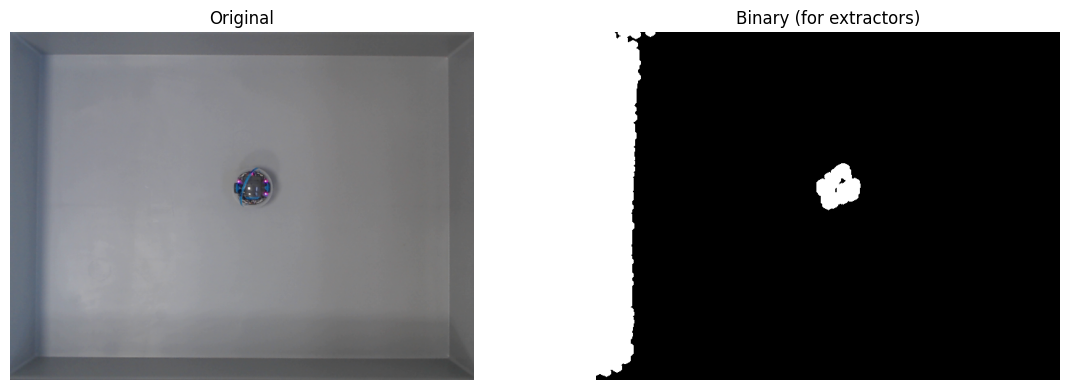

In [18]:
# ── Binary image for extractor testing ───────────────────────────────────────
# Adjust the HSV range to isolate your target object before running extractors.

LOWER_HUE  = 90;  UPPER_HUE  = 130
LOWER_SAT  = 50;  UPPER_SAT  = 255
LOWER_VAL  = 50;  UPPER_VAL  = 255
DIL_KERNEL = (7, 7)
DIL_ITER   = 2

_prep = ImagePipeline([
    HSVProcessor(
        lower_hue=LOWER_HUE, upper_hue=UPPER_HUE,
        lower_sat=LOWER_SAT, upper_sat=UPPER_SAT,
        lower_val=LOWER_VAL, upper_val=UPPER_VAL,
        apply_mask=True,
    ),
    DilationProcessor(kernel_size=DIL_KERNEL, iterations=DIL_ITER),
])
binary_for_extractors = _prep.execute(raw_image)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(raw_image);                           axes[0].set_title("Original");                 axes[0].axis("off")
axes[1].imshow(binary_for_extractors, cmap="gray");    axes[1].set_title("Binary (for extractors)");   axes[1].axis("off")
plt.tight_layout()
plt.show()

[HoughCircle]  detected: (334, 214)


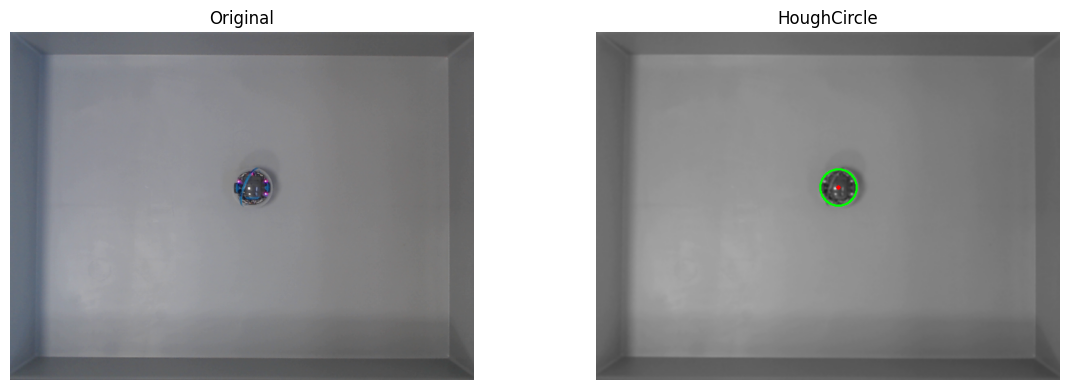

In [19]:
# ── HoughCircleExtractor ──────────────────────────────────────────────────────
# Detects circles using the Hough gradient method.
# Works best on a blurred grayscale image (NOT a hard binary mask).

HOUGH_DP         = 1.2
HOUGH_MIN_DIST   = 50
HOUGH_PARAM1     = 100    # Canny upper threshold used internally
HOUGH_PARAM2     = 30     # accumulator threshold — lower = more circles detected
HOUGH_MIN_RADIUS = 10
HOUGH_MAX_RADIUS = 100

extractor = HoughCircleExtractor(
    hough_dp=HOUGH_DP,
    hough_min_dist=HOUGH_MIN_DIST,
    hough_param1=HOUGH_PARAM1,
    hough_param2=HOUGH_PARAM2,
    hough_min_radius=HOUGH_MIN_RADIUS,
    hough_max_radius=HOUGH_MAX_RADIUS,
)

_input   = cv.GaussianBlur(gray_image, (3, 3), 2)   # Hough works better on blurred input
location = extractor.extract(_input)
debug    = extractor.get_debug_image(_input)

print(f"[{extractor.name}]  detected: {location.as_tuple() if location else 'None'}")
show_result(debug, extractor.name)

[Contour]  detected : (25, 226)
               circularity=0.223  area=24188.5


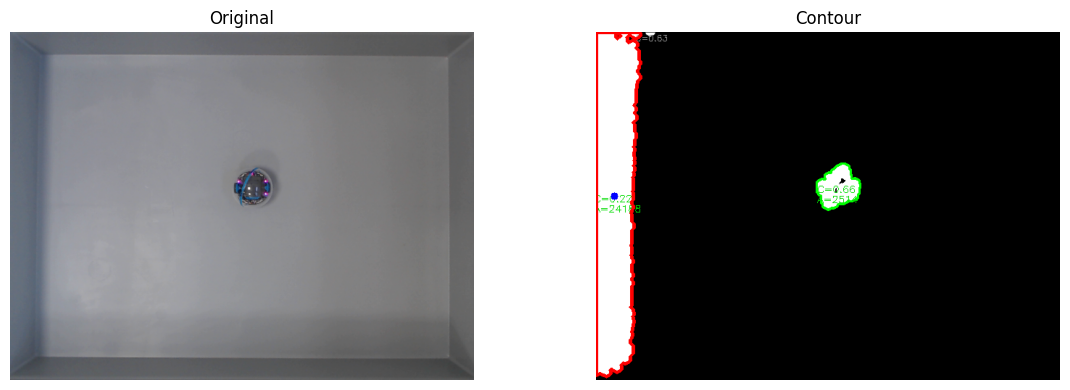

In [20]:
# ── ContourExtractor ──────────────────────────────────────────────────────────
# Finds external contours, filters by area + circularity,
# returns centroid of the largest valid contour.

MIN_CONTOUR_AREA = 100
MAX_CONTOUR_AREA = None   # None = no upper limit
MIN_CIRCULARITY  = 0.0    # 0.0 = disabled; 0.6 = good for Sphero BOLT+

extractor = ContourExtractor(
    min_contour_area=MIN_CONTOUR_AREA,
    max_contour_area=MAX_CONTOUR_AREA,
    min_circularity=MIN_CIRCULARITY,
)
location = extractor.extract(binary_for_extractors)
debug    = extractor.get_debug_image(binary_for_extractors)

print(f"[{extractor.name}]  detected : {location.as_tuple() if location else 'None'}")
print(f"               circularity={extractor.last_circularity}  area={extractor.last_area}")
show_result(debug, extractor.name)

[Moments]  detected: (333, 213)


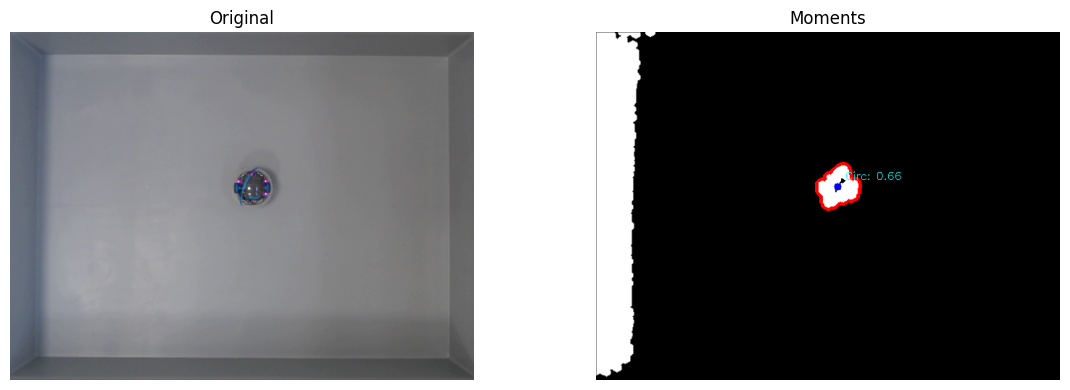

In [21]:
# ── MomentsExtractor
# Uses image moments to find the centroid of the most circular contour.
# Selects the contour with the highest circularity score (not just the largest).

MIN_CONTOUR_AREA = 100
MIN_CIRCULARITY  = 0.4    # reject non-round shapes

extractor = MomentsExtractor(
    min_contour_area=MIN_CONTOUR_AREA,
    min_circularity=MIN_CIRCULARITY,
)
location = extractor.extract(binary_for_extractors)
debug    = extractor.get_debug_image(binary_for_extractors)

print(f"[{extractor.name}]  detected: {location.as_tuple() if location else 'None'}")
show_result(debug, extractor.name)

[PolygonApprox]  detected: (333, 215)


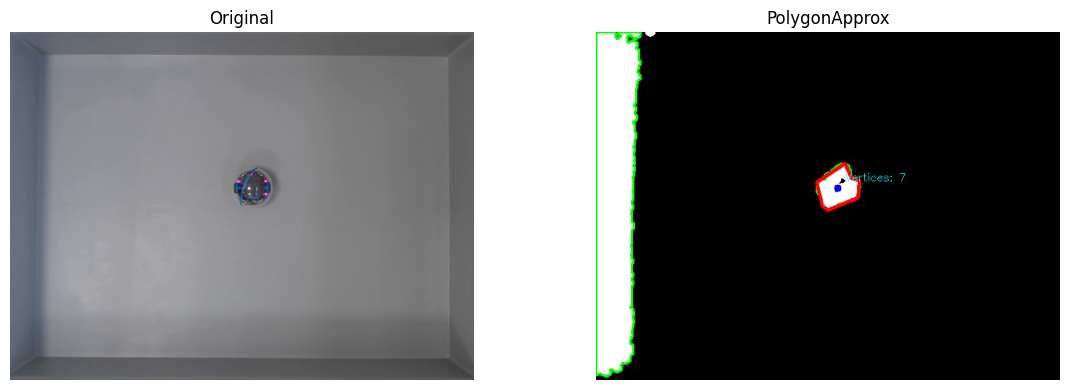

In [22]:
# ── PolygonApproxExtractor ────────────────────────────────────────────────────
# Approximates contours as polygons; selects those closest to TARGET_VERTICES
# (8-sided polygon ≈ circle). More robust to noisy contour boundaries.

MIN_CONTOUR_AREA = 100
EPSILON_FACTOR   = 0.02   # lower = tighter approximation
TARGET_VERTICES  = 8

extractor = PolygonApproxExtractor(
    min_contour_area=MIN_CONTOUR_AREA,
    epsilon_factor=EPSILON_FACTOR,
    target_vertices=TARGET_VERTICES,
)
location = extractor.extract(binary_for_extractors)
debug    = extractor.get_debug_image(binary_for_extractors)

print(f"[{extractor.name}]  detected: {location.as_tuple() if location else 'None'}")
show_result(debug, extractor.name)

---
## 4 · Custom Pipeline Builder
Add, remove, or reorder steps — then run the cell to see every intermediate stage.

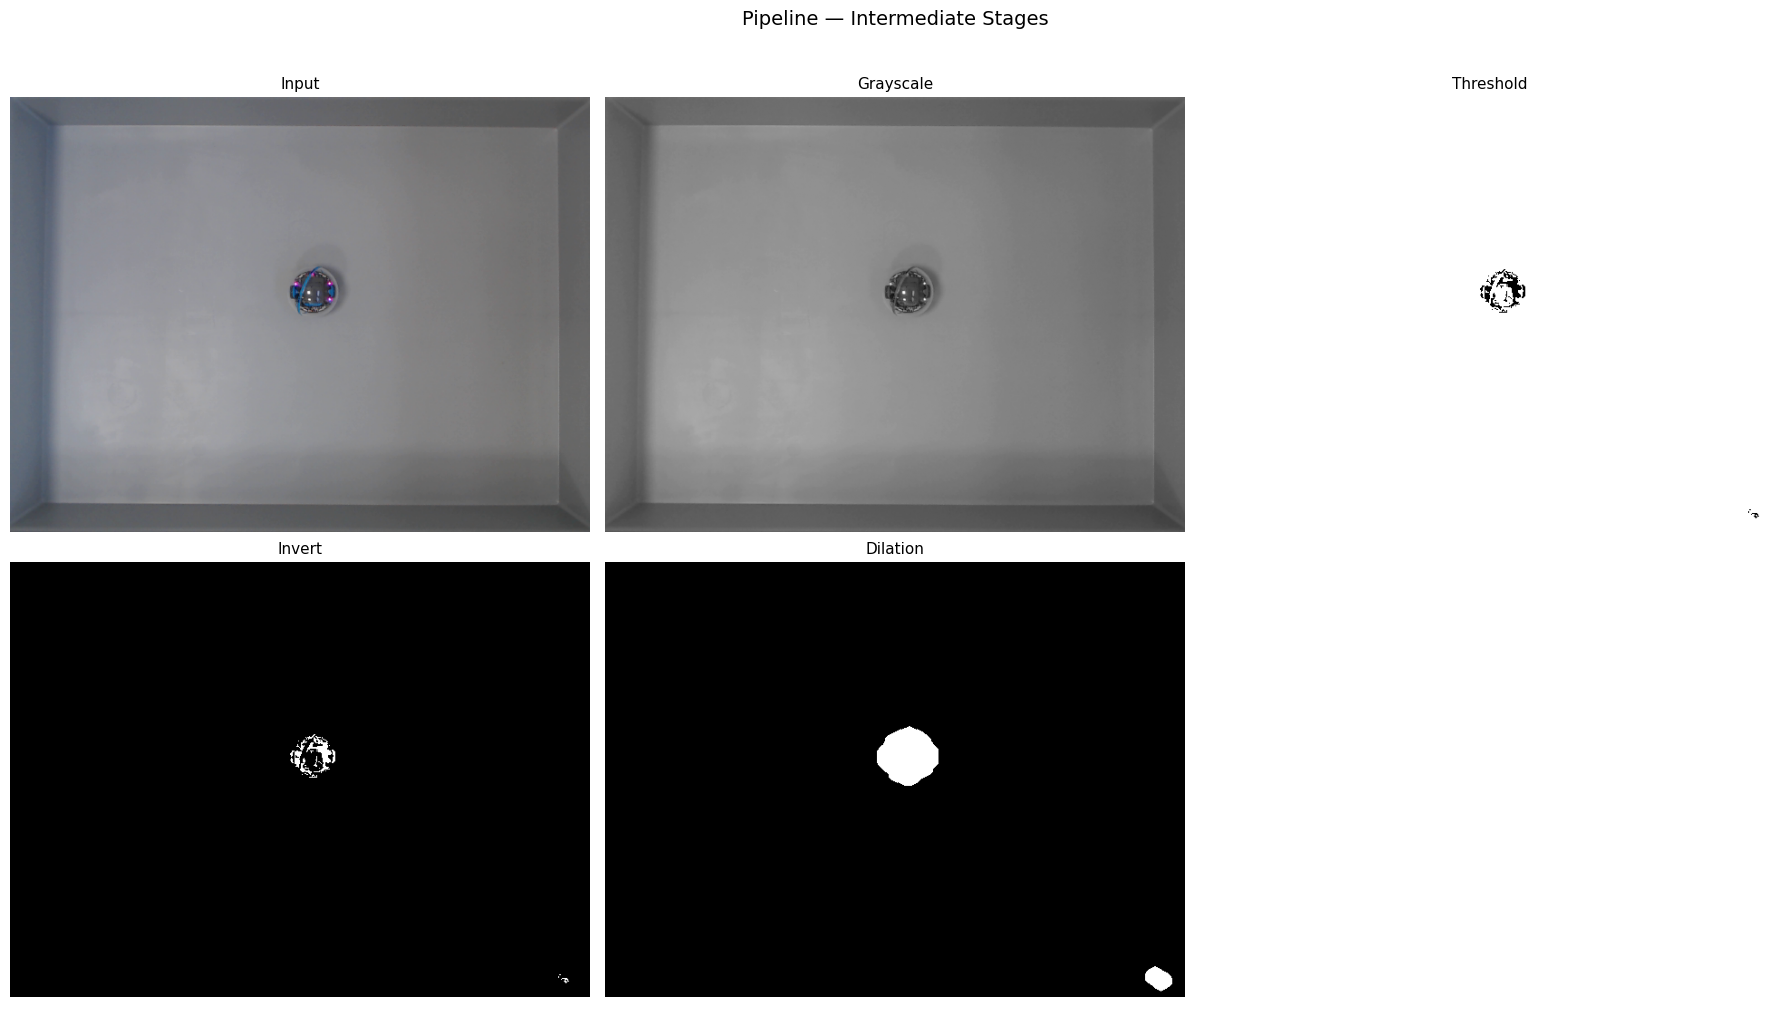

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# Assemble your pipeline here
# ══════════════════════════════════════════════════════════════════════════════

pipeline = ImagePipeline([
    # ── active steps ──────────────────────────────────────────────────────────
    GrayscaleProcessor(),
    ThresholdProcessor(threshold_value=65, max_value=255),
    InvertProcessor(),
    DilationProcessor(kernel_size=(7, 7), iterations=3),

    # ── commented-out steps (uncomment to enable) ─────────────────────────────
    # GrayscaleProcessor(),
    # GaussianBlurProcessor(kernel_size=9, sigma=2.0),
    # CannyProcessor(threshold1=50, threshold2=150),
    # LaplacianProcessor(ksize=3),
    # ThresholdProcessor(threshold_value=127),
    # ErosionProcessor(kernel_size=(3, 3), iterations=1),
    # CLAHEProcessor(clip_limit=3.0, tile_grid_size=(8, 8)),
    # FFTBandpassProcessor(low_freq=10, high_freq=80),
    #
    # ── MaskIntersectionProcessor (replaces the gray steps above) ─────────────
    # MaskIntersectionProcessor(
    #     pipeline_a=ImagePipeline([                # bright-pixel mask
    #         GrayscaleProcessor(),
    #         ThresholdProcessor(threshold_value=60),
    #         InvertProcessor(),
    #     ]),
    #     pipeline_b=ImagePipeline([                # color mask
    #         HSVProcessor(
    #             lower_hue=90, upper_hue=130,
    #             lower_sat=80, upper_sat=255,
    #             lower_val=100, upper_val=255,
    #             apply_mask=True,
    #         ),
    #     ]),
    # ),
])

# Run pipeline and collect intermediate images
pipeline.execute(raw_image, debug=True)
stages = pipeline.get_intermediate_results()   # [input, after_step_1, after_step_2, ...]

stage_labels = ["Input"] + [
    type(s).__name__.replace("Processor", "") for s in pipeline.steps
]

n      = len(stages)
COLS   = 3                          # ← adjust columns per row
ROWS   = math.ceil(n / COLS)
fig, axes = plt.subplots(ROWS, COLS, figsize=(6 * COLS, 5 * ROWS))
axes = np.array(axes).flatten()     # always a flat list

for ax, img, lbl in zip(axes, stages, stage_labels):
    if img.ndim == 2:
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        ax.imshow(img)
    ax.set_title(lbl, fontsize=11)
    ax.axis("off")

# Hide unused subplots
for ax in axes[n:]:
    ax.axis("off")

plt.suptitle("Pipeline — Intermediate Stages", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5 · End-to-End Test
Run the pipeline defined above through a chosen extractor and visualise the detection result.

[Contour]  Ball location: (333, 213)


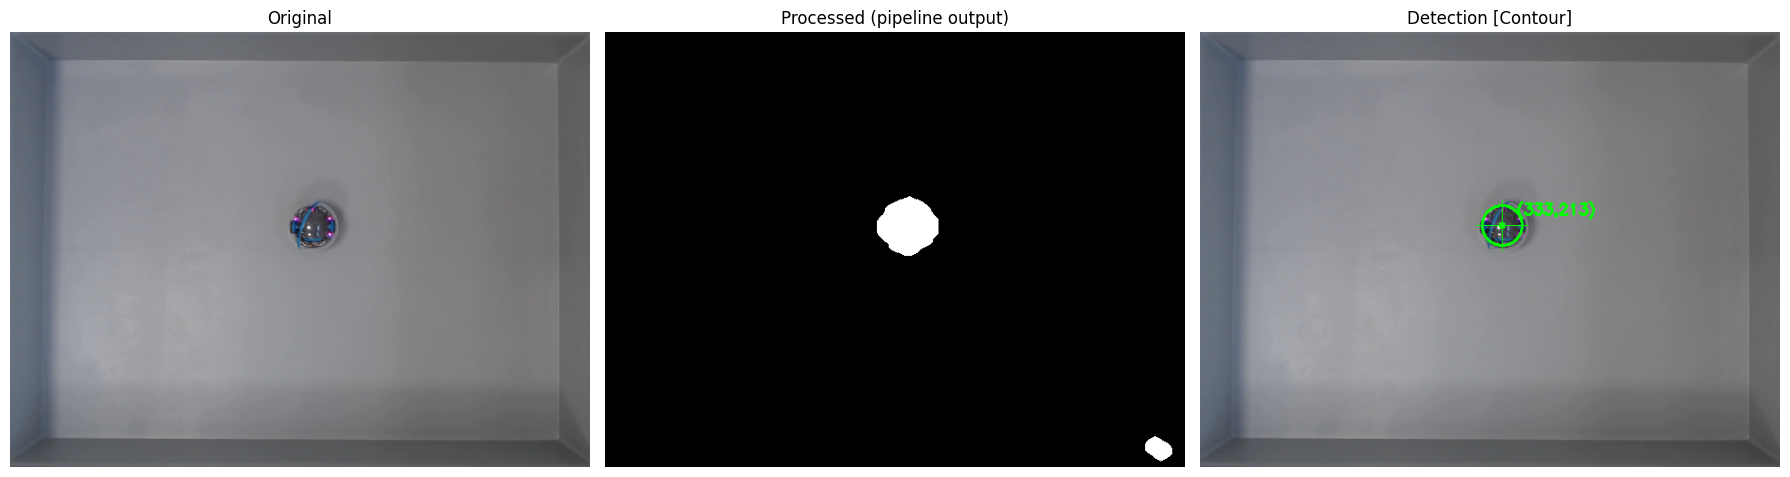

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# End-to-end: pipeline  →  extractor  →  annotated image
# ══════════════════════════════════════════════════════════════════════════════

# Re-use the pipeline from the cell above (modify there if needed)
processed = pipeline.execute(raw_image)

# ── Choose extractor ──────────────────────────────────────────────────────────
extractor = ContourExtractor()
# extractor = MomentsExtractor(min_contour_area=100, min_circularity=0.4)
# extractor = PolygonApproxExtractor(min_contour_area=100)
# extractor = HoughCircleExtractor()   # NOTE: pass gray_image / blurred image, not a binary mask

location = extractor.extract(processed)
print(f"[{extractor.name}]  Ball location: {location.as_tuple() if location else 'NOT DETECTED'}")

# ── Annotate original image ───────────────────────────────────────────────────
# Draw result on a copy of the original (raw_image is RGB, so are annotation colours)
annotated = raw_image.copy()
if location:
    cx, cy = location.x, location.y
    cv.circle(annotated, (cx, cy), 22, (0, 255, 0), 2)
    cv.circle(annotated, (cx, cy),  4, (0, 255, 0), -1)
    cv.line(annotated, (cx - 28, cy), (cx + 28, cy), (0, 255, 0), 1)
    cv.line(annotated, (cx, cy - 28), (cx, cy + 28), (0, 255, 0), 1)
    cv.putText(annotated, f"({cx},{cy})", (cx + 16, cy - 12),
               cv.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(raw_image);   axes[0].set_title("Original");                      axes[0].axis("off")
axes[1].imshow(_to_rgb(processed));  axes[1].set_title("Processed (pipeline output)");   axes[1].axis("off")
axes[2].imshow(annotated);   axes[2].set_title(f"Detection [{extractor.name}]"); axes[2].axis("off")
plt.tight_layout()
plt.show()